# Notebook 14 — K-Means y evaluación de clustering

En este notebook estudiaremos cómo K-Means agrupa observaciones a partir de su cercanía a centroides y cómo evaluar la calidad de una solución de clustering.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- explicar la intuición de K-Means;
- interpretar centroides y asignaciones;
- ajustar `KMeans` con `scikit-learn`;
- comprender el papel de la inicialización;
- analizar la inercia;
- utilizar el método del codo;
- calcular e interpretar Silhouette Score;
- comparar soluciones con diferentes valores de \(K\);
- comprender la importancia del escalamiento;
- analizar la estabilidad entre inicializaciones;
- reconocer limitaciones de K-Means.

Usaremos datos sintéticos generados con `make_blobs`.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

pd.options.display.float_format = "{:,.4f}".format


## 2. Generación de datos sintéticos

Crearemos cuatro grupos con distinta dispersión.

Las etiquetas verdaderas se conservarán únicamente con fines didácticos. En un problema no supervisado real, normalmente no existirían.

In [2]:
X, true_labels = make_blobs(
    n_samples=800,
    centers=4,
    cluster_std=[0.65, 1.10, 0.85, 1.30],
    random_state=RANDOM_STATE,
)

data = pd.DataFrame(
    X,
    columns=["x1", "x2"],
)

data["etiqueta_real"] = true_labels

data.head()


,x1,x2,etiqueta_real
0,-9.3430,7.5451,3
1,-6.4121,-7.7032,2
2,3.7704,2.4918,1
3,3.8651,0.4239,1
4,5.2556,3.1620,1


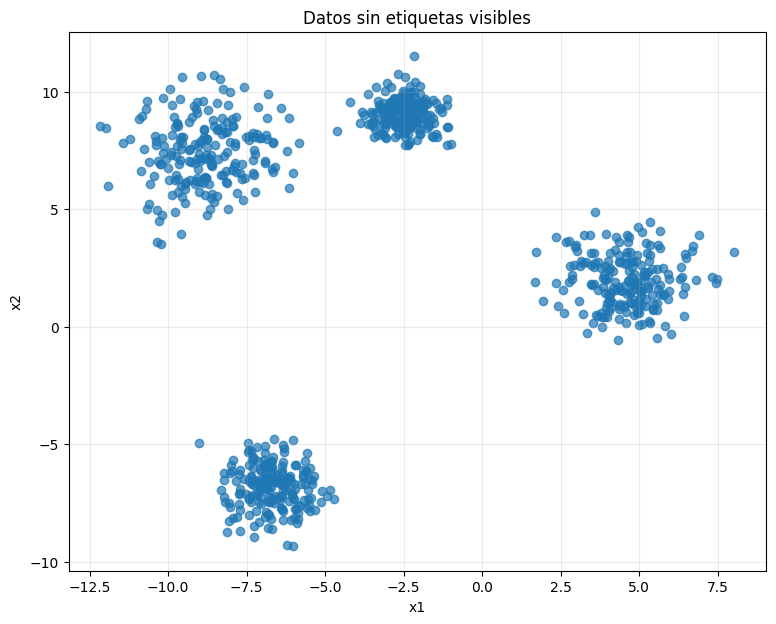

In [3]:
plt.figure(figsize=(9, 7))
plt.scatter(
    data["x1"],
    data["x2"],
    alpha=0.70,
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Datos sin etiquetas visibles")
plt.grid(alpha=0.25)
plt.show()


## 3. Intuición de K-Means

K-Means busca dividir los datos en \(K\) grupos minimizando la suma de distancias cuadráticas a los centroides:

\[
\sum_{k=1}^{K}
\sum_{x_i\in C_k}
\lVert x_i-\mu_k\rVert^2.
\]

El algoritmo alterna dos pasos:

1. asignar cada observación al centroide más cercano;
2. recalcular cada centroide como el promedio del grupo.

## 4. Primer ajuste con \(K=4\)

In [4]:
kmeans = KMeans(
    n_clusters=4,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE,
)

cluster_labels = kmeans.fit_predict(
    data[["x1", "x2"]]
)

data["cluster_kmeans"] = cluster_labels

print("Inercia:", kmeans.inertia_)
print("Centroides:")
print(kmeans.cluster_centers_)


Inercia: 1618.7424063191183
Centroides:
[[-6.71137742 -6.82091916]
 [-2.51466104  9.03596631]
 [ 4.5875585   1.94817945]
 [-8.82411056  7.40980134]]


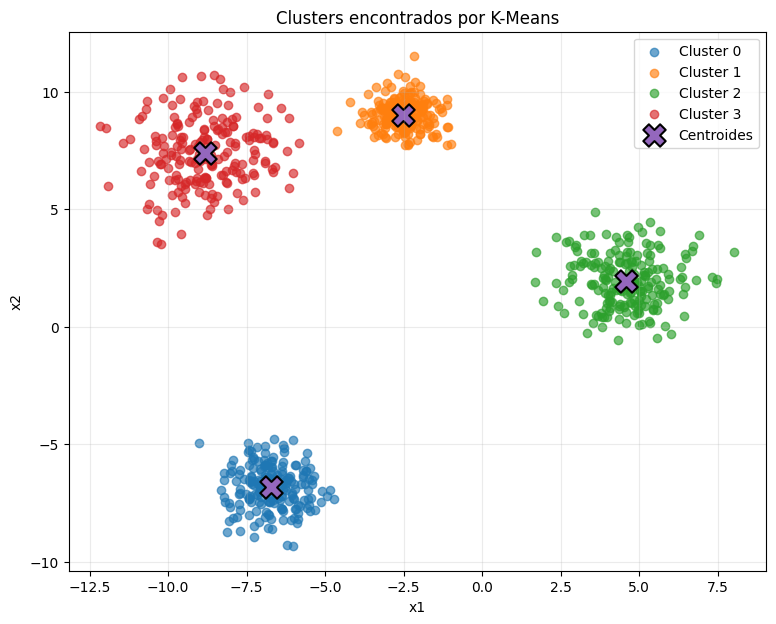

In [5]:
plt.figure(figsize=(9, 7))

for cluster_value in sorted(data["cluster_kmeans"].unique()):
    mask = data["cluster_kmeans"] == cluster_value

    plt.scatter(
        data.loc[mask, "x1"],
        data.loc[mask, "x2"],
        alpha=0.65,
        label=f"Cluster {cluster_value}",
    )

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=260,
    edgecolors="black",
    linewidths=1.5,
    label="Centroides",
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Clusters encontrados por K-Means")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


Los identificadores de cluster son arbitrarios. El cluster 0 no tiene una interpretación ordinal frente al cluster 1.

## 5. Asignación de nuevas observaciones

In [6]:
new_points = np.array([
    [-8, 6],
    [-2, 8],
    [4, 2],
    [9, 7],
])

new_assignments = kmeans.predict(
    new_points
)

pd.DataFrame({
    "x1": new_points[:, 0],
    "x2": new_points[:, 1],
    "Cluster asignado": new_assignments,
})


/Users/brauliopinaamaros/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


,x1,x2,Cluster asignado
0,-8,6,3
1,-2,8,1
2,4,2,2
3,9,7,2


Cada nueva observación se asigna al centroide más cercano.

## 6. Método del codo

La inercia siempre disminuye al aumentar \(K\). El método del codo busca un punto a partir del cual la mejora marginal se vuelve pequeña.

In [7]:
k_values = range(1, 11)
inertia_values = []

for k_value in k_values:
    model = KMeans(
        n_clusters=k_value,
        init="k-means++",
        n_init=20,
        random_state=RANDOM_STATE,
    )

    model.fit(
        data[["x1", "x2"]]
    )

    inertia_values.append(
        model.inertia_
    )

elbow_table = pd.DataFrame({
    "K": list(k_values),
    "Inercia": inertia_values,
})

elbow_table


,K,Inercia
0,1,"53,290.1088"
1,2,"25,141.0085"
2,3,"5,864.0990"
3,4,"1,618.7424"
4,5,"1,361.2545"
5,6,"1,189.1799"
6,7,"1,046.6443"
7,8,939.5374
8,9,832.6669
9,10,764.1441


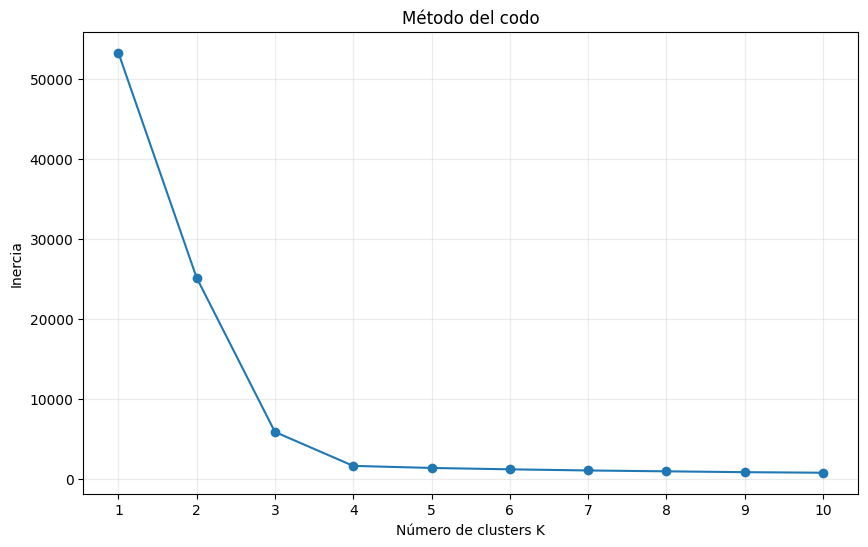

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(
    elbow_table["K"],
    elbow_table["Inercia"],
    marker="o",
)
plt.xlabel("Número de clusters K")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.xticks(list(k_values))
plt.grid(alpha=0.25)
plt.show()


El codo puede ser ambiguo. No debe interpretarse como una regla automática.

## 7. Silhouette Score

Para cada observación, el coeficiente Silhouette compara:

- cohesión dentro de su cluster;
- separación respecto al cluster vecino más cercano.

Su rango es aproximadamente:

\[
-1 \leq s(i) \leq 1.
\]

- cercano a 1: buena asignación;
- cercano a 0: observación en una frontera;
- negativo: posible asignación incorrecta.

In [9]:
silhouette_rows = []

for k_value in range(2, 11):
    model = KMeans(
        n_clusters=k_value,
        init="k-means++",
        n_init=20,
        random_state=RANDOM_STATE,
    )

    labels = model.fit_predict(
        data[["x1", "x2"]]
    )

    silhouette_rows.append({
        "K": k_value,
        "Silhouette medio": silhouette_score(
            data[["x1", "x2"]],
            labels,
        ),
        "Inercia": model.inertia_,
    })

silhouette_table = pd.DataFrame(
    silhouette_rows
)

silhouette_table


,K,Silhouette medio,Inercia
0,2,0.5915,"25,141.0085"
1,3,0.7551,"5,864.0990"
2,4,0.7908,"1,618.7424"
3,5,0.7120,"1,361.2545"
4,6,0.5976,"1,189.1799"
5,7,0.5901,"1,046.6443"
6,8,0.5911,939.5374
7,9,0.4585,832.6669
8,10,0.4584,764.1441


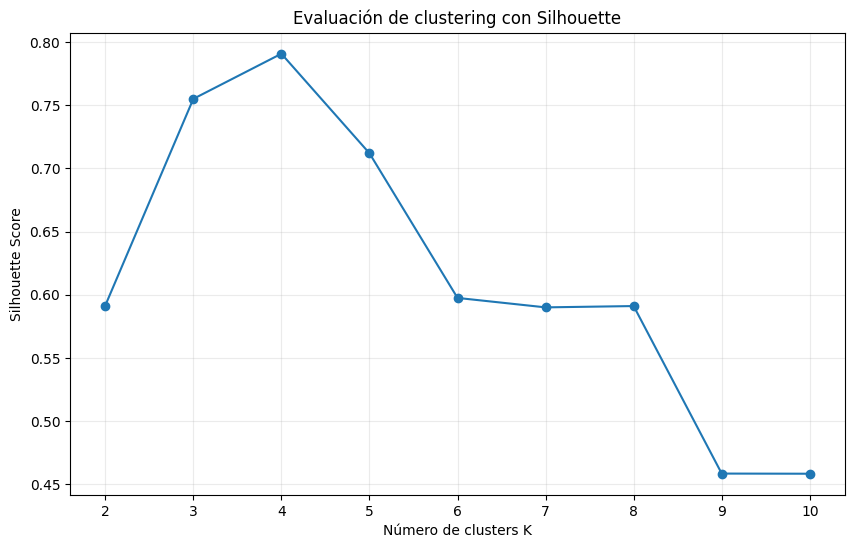

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(
    silhouette_table["K"],
    silhouette_table["Silhouette medio"],
    marker="o",
)
plt.xlabel("Número de clusters K")
plt.ylabel("Silhouette Score")
plt.title("Evaluación de clustering con Silhouette")
plt.grid(alpha=0.25)
plt.show()


Una solución con mayor Silhouette suele mostrar grupos compactos y separados, aunque la métrica también favorece ciertas geometrías.

## 8. Silhouette por observación

In [11]:
sample_silhouette = silhouette_samples(
    data[["x1", "x2"]],
    data["cluster_kmeans"],
)

data["silhouette_individual"] = sample_silhouette

data[
    [
        "x1",
        "x2",
        "cluster_kmeans",
        "silhouette_individual",
    ]
].head()


,x1,x2,cluster_kmeans,silhouette_individual
0,-9.3430,7.5451,3,0.7519
1,-6.4121,-7.7032,0,0.9068
2,3.7704,2.4918,2,0.8165
3,3.8651,0.4239,2,0.8071
4,5.2556,3.1620,2,0.8037


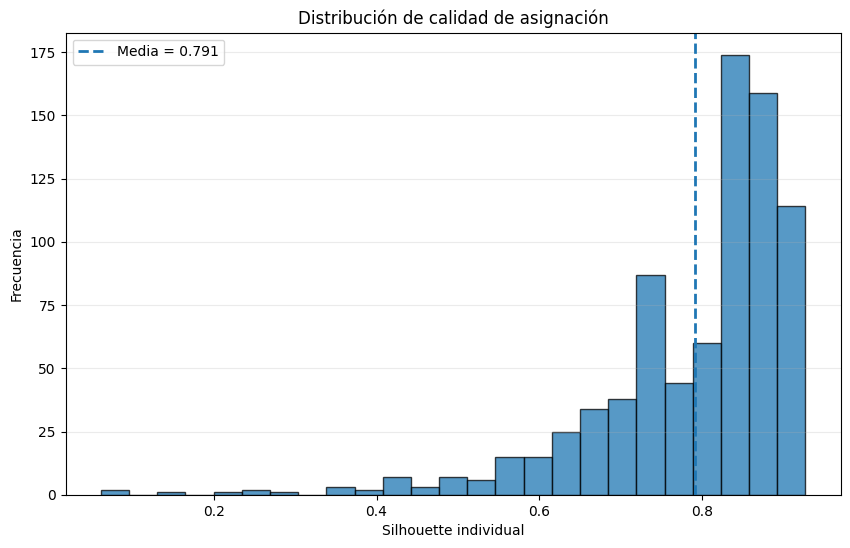

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(
    data["silhouette_individual"],
    bins=25,
    edgecolor="black",
    alpha=0.75,
)
plt.axvline(
    data["silhouette_individual"].mean(),
    linestyle="--",
    linewidth=2,
    label=(
        f"Media = "
        f"{data['silhouette_individual'].mean():.3f}"
    ),
)
plt.xlabel("Silhouette individual")
plt.ylabel("Frecuencia")
plt.title("Distribución de calidad de asignación")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


Las observaciones con Silhouette bajo o negativo pueden encontrarse en zonas de traslape.

In [13]:
data.sort_values(
    "silhouette_individual"
).head(15)


,x1,x2,etiqueta_real,cluster_kmeans,silhouette_individual
97,-5.8232,7.8348,3,3,0.0616
540,-6.1584,8.8944,3,3,0.0913
128,-6.3884,9.3297,3,3,0.1354
475,-6.8336,9.9314,3,3,0.2152
411,-6.0338,6.5361,3,3,0.2503
50,-6.2209,7.5010,3,3,0.2648
521,-6.1653,5.8894,3,3,0.3007
579,-6.8484,8.9079,3,3,0.3453
630,-7.5853,10.1972,3,3,0.3616
576,-7.1461,9.3535,3,3,0.3727


## 9. Comparación visual de distintos valores de \(K\)

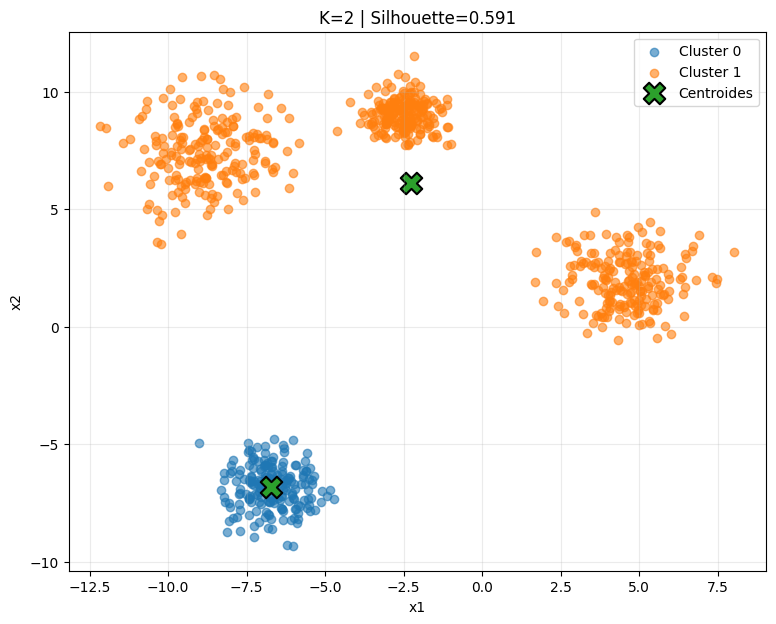

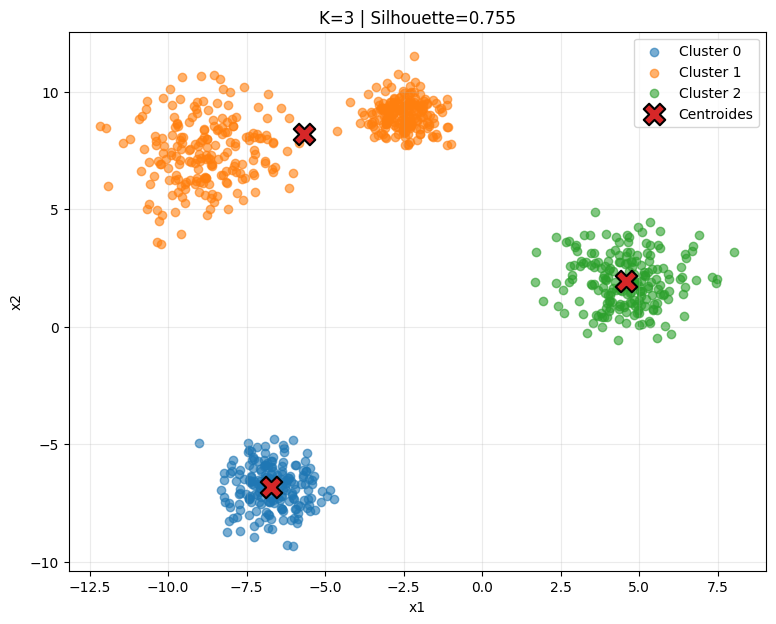

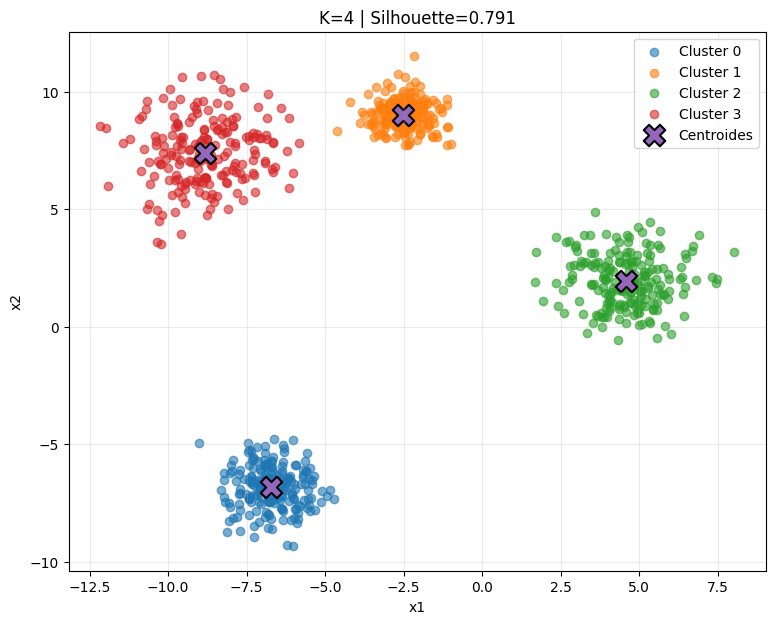

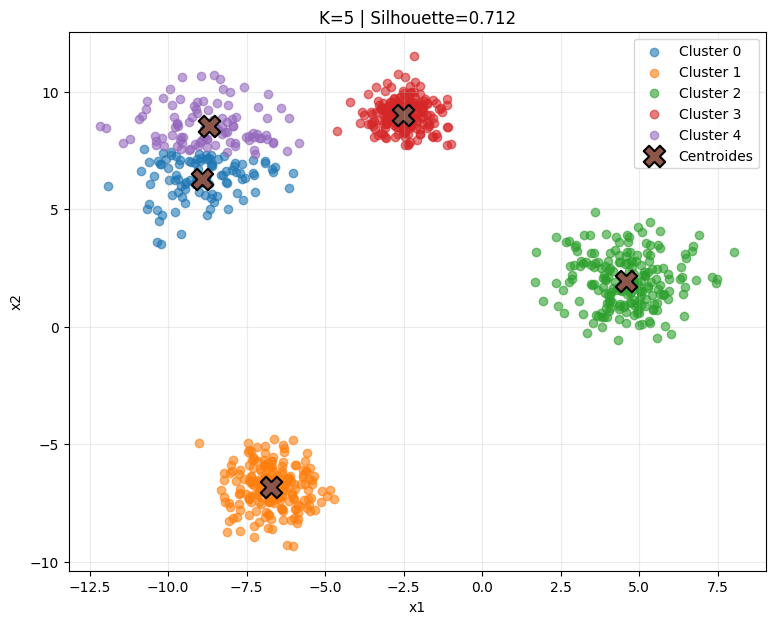

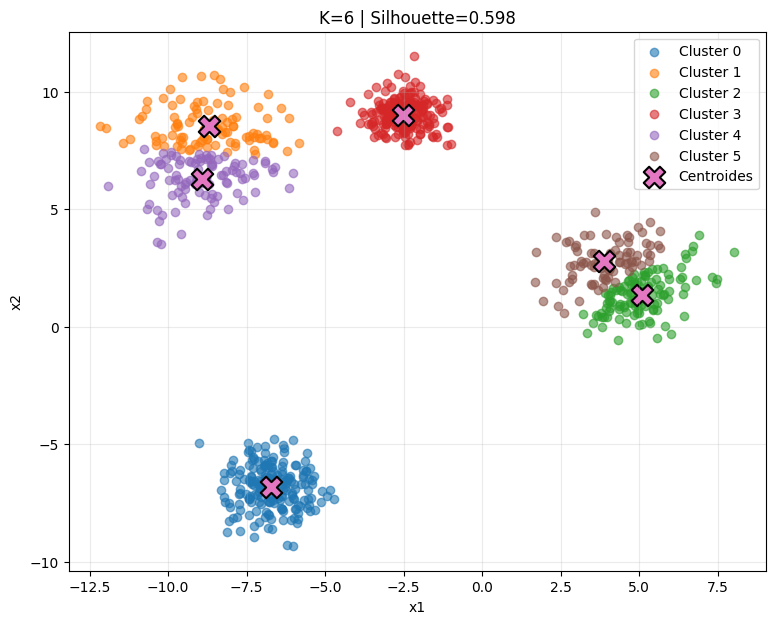

In [14]:
for k_value in [2, 3, 4, 5, 6]:
    model = KMeans(
        n_clusters=k_value,
        n_init=20,
        random_state=RANDOM_STATE,
    )

    labels = model.fit_predict(
        data[["x1", "x2"]]
    )

    plt.figure(figsize=(9, 7))

    for cluster_value in np.unique(labels):
        mask = labels == cluster_value

        plt.scatter(
            data.loc[mask, "x1"],
            data.loc[mask, "x2"],
            alpha=0.6,
            label=f"Cluster {cluster_value}",
        )

    plt.scatter(
        model.cluster_centers_[:, 0],
        model.cluster_centers_[:, 1],
        marker="X",
        s=240,
        edgecolors="black",
        linewidths=1.5,
        label="Centroides",
    )

    score = silhouette_score(
        data[["x1", "x2"]],
        labels,
    )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(
        f"K={k_value} | Silhouette={score:.3f}"
    )
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## 10. Importancia del escalamiento

K-Means utiliza distancias euclidianas. Una variable con una escala grande puede dominar las asignaciones.

In [15]:
X_scale_example = data[
    ["x1", "x2"]
].copy()

X_scale_example["x2"] = (
    X_scale_example["x2"] * 10_000
)

kmeans_without_scaling = KMeans(
    n_clusters=4,
    n_init=20,
    random_state=RANDOM_STATE,
)

labels_without_scaling = kmeans_without_scaling.fit_predict(
    X_scale_example
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(
    X_scale_example
)

kmeans_with_scaling = KMeans(
    n_clusters=4,
    n_init=20,
    random_state=RANDOM_STATE,
)

labels_with_scaling = kmeans_with_scaling.fit_predict(
    X_scaled
)

pd.DataFrame({
    "Modelo": [
        "Sin escalamiento",
        "Con escalamiento",
    ],
    "Silhouette": [
        silhouette_score(
            X_scale_example,
            labels_without_scaling,
        ),
        silhouette_score(
            X_scaled,
            labels_with_scaling,
        ),
    ],
})


,Modelo,Silhouette
0,Sin escalamiento,0.7125
1,Con escalamiento,0.7988


En aprendizaje no supervisado no existe una variable objetivo que “corrija” automáticamente el efecto de una escala inadecuada.

## 11. Inicialización y estabilidad

K-Means puede converger a soluciones locales distintas según los centroides iniciales.

`k-means++` y múltiples inicializaciones ayudan a mejorar la estabilidad.

In [16]:
initialization_rows = []

for seed in range(30):
    model = KMeans(
        n_clusters=4,
        init="random",
        n_init=1,
        random_state=seed,
    )

    labels = model.fit_predict(
        data[["x1", "x2"]]
    )

    initialization_rows.append({
        "Semilla": seed,
        "Inercia": model.inertia_,
        "Silhouette": silhouette_score(
            data[["x1", "x2"]],
            labels,
        ),
    })

initialization_table = pd.DataFrame(
    initialization_rows
)

initialization_table.describe()


,Semilla,Inercia,Silhouette
count,30.0000,30.0000,30.0000
mean,14.5000,"3,264.4080",0.7196
std,8.8034,"2,050.0497",0.0887
min,0.0000,"1,618.7424",0.6053
25%,7.2500,"1,618.7424",0.6147
50%,14.5000,"1,618.7424",0.7908
75%,21.7500,"5,714.0227",0.7908
max,29.0000,"5,761.1999",0.7908


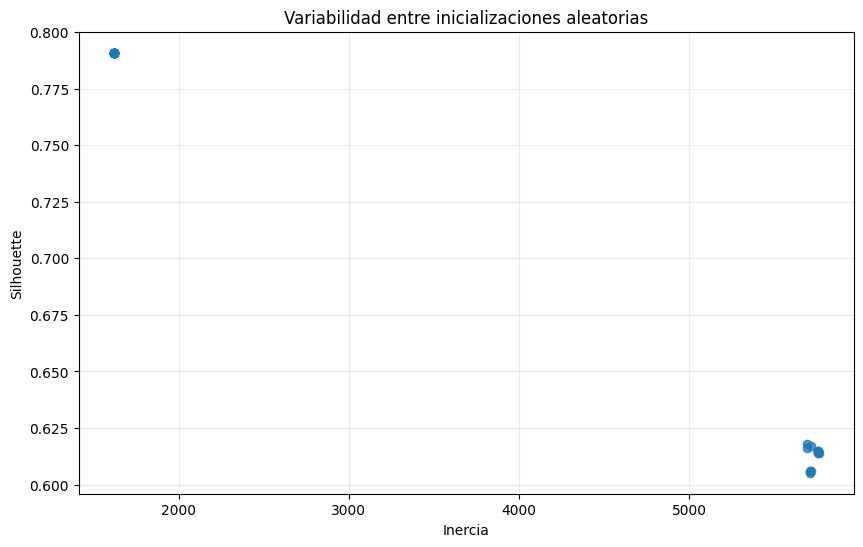

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(
    initialization_table["Inercia"],
    initialization_table["Silhouette"],
    alpha=0.75,
)
plt.xlabel("Inercia")
plt.ylabel("Silhouette")
plt.title("Variabilidad entre inicializaciones aleatorias")
plt.grid(alpha=0.25)
plt.show()


Con `n_init>1`, `scikit-learn` conserva la mejor solución encontrada según inercia.

## 12. Comparación con etiquetas verdaderas

Como este dataset es sintético, conocemos las clases generadoras.

Usaremos Adjusted Rand Index solo con fines didácticos.

In [18]:
ari = adjusted_rand_score(
    data["etiqueta_real"],
    data["cluster_kmeans"],
)

print(
    "Adjusted Rand Index:",
    ari,
)


Adjusted Rand Index: 1.0


ARI compara dos particiones ignorando el nombre arbitrario de los clusters.

En un problema real sin etiquetas, no estaría disponible.

## 13. Geometría esperada por K-Means

K-Means funciona mejor cuando los grupos son aproximadamente:

- compactos;
- esféricos;
- de tamaño parecido;
- de densidad similar.

Puede fallar con:

- clusters alargados;
- formas no convexas;
- densidades muy distintas;
- muchos outliers.

## 14. Errores frecuentes

1. Elegir \(K\) solo porque “se ve bien”.
2. Usar el codo como regla infalible.
3. No escalar variables.
4. Interpretar los números de cluster como ordenados.
5. Suponer que menor inercia siempre significa mejor solución.
6. Comparar inercia entre datasets escalados de forma diferente.
7. Usar una sola inicialización.
8. Ignorar outliers.
9. Interpretar clusters como segmentos reales sin validación sustantiva.
10. Evaluar únicamente con una métrica interna.

## 15. Experimentos sugeridos

### Experimento 1

Cambia \(K\) entre 2 y 12.

### Experimento 2

Compara `init="random"` y `init="k-means++"`.

### Experimento 3

Cambia `n_init`.

### Experimento 4

Multiplica una variable por 1,000 y repite el análisis.

### Experimento 5

Agrega outliers.

### Experimento 6

Genera clusters con dispersiones muy distintas.

### Experimento 7

Usa `make_moons` y compara K-Means contra DBSCAN.

### Experimento 8

Revisa observaciones con Silhouette negativo.

### Experimento 9

Compara la solución con y sin PCA previo.

### Experimento 10

Analiza la estabilidad de los centroides entre semillas.

## 16. Resumen

En este notebook:

- ajustamos K-Means;
- interpretamos centroides y asignaciones;
- analizamos inercia;
- usamos el método del codo;
- calculamos Silhouette Score;
- revisamos calidad por observación;
- comparamos distintos valores de \(K\);
- demostramos la importancia del escalamiento;
- analizamos estabilidad entre inicializaciones;
- comparamos con etiquetas verdaderas mediante ARI;
- discutimos las geometrías apropiadas para K-Means.

K-Means es simple y eficiente, pero sus resultados dependen de la escala, la inicialización, la elección de \(K\) y la geometría real de los datos.